#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---



## Task 1: Import Libraries and Load the Dataset

In [1]:
# Task 1: Import Libraries and Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
DATA_PATH = 'amazon_alexa.tsv'
print(f'Loading data from: {DATA_PATH}')

Loading data from: amazon_alexa.tsv


In [3]:
# Load the dataset into a DataFrame and preview the first few rows.
df = pd.read_csv(DATA_PATH, sep='\t')
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [4]:
df.shape

(3150, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [6]:
# Check for missing values
df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [8]:
# One review is missing text (NaN)
df = df.dropna(subset=['verified_reviews']).reset_index(drop=True)
df.shape

(3149, 5)

## Task 2: Data Visualization

Let's look at the balance of the target variable and how rating varies across product variations.

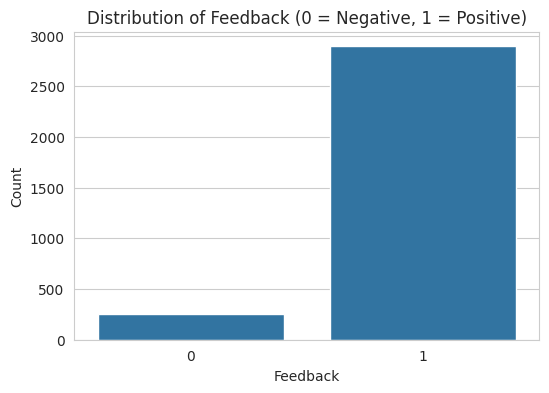

,count
feedback,
1,2893
0,256


In [9]:
# Visualize the distribution of feedback (positive/negative)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='feedback')
plt.title('Distribution of Feedback (0 = Negative, 1 = Positive)')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

df['feedback'].value_counts()

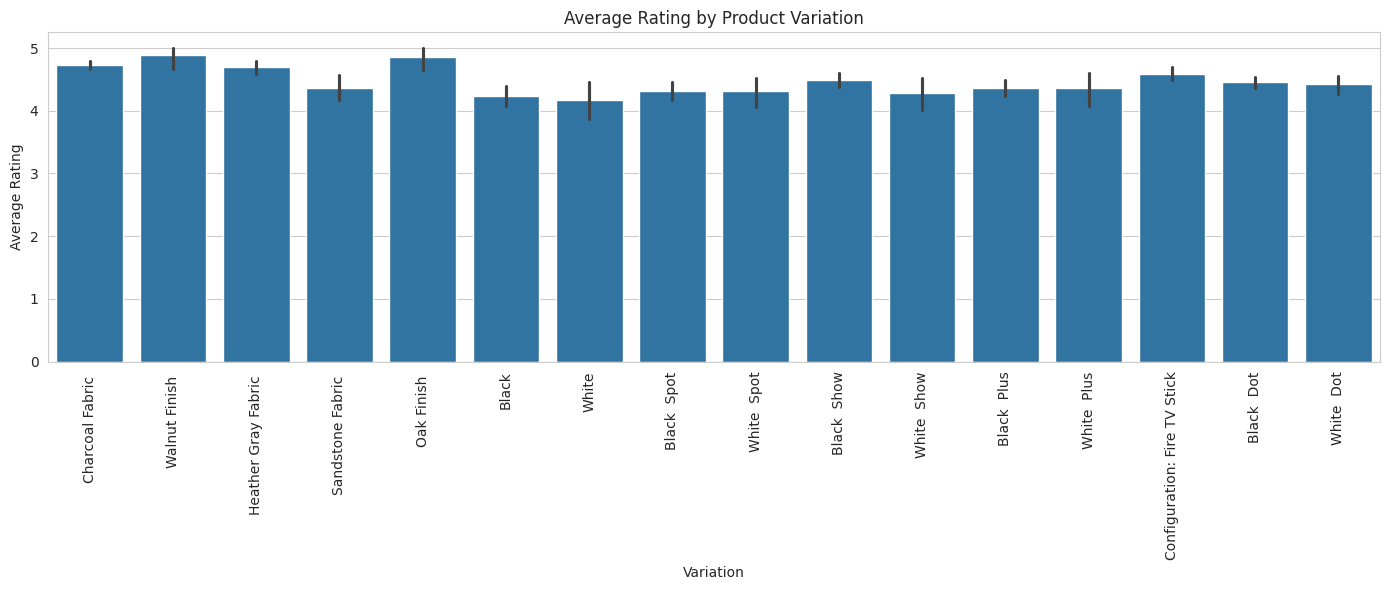

In [10]:
# Visualize the relationship between product variation and rating
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='variation', y='rating')
plt.xticks(rotation=90)
plt.title('Average Rating by Product Variation')
plt.xlabel('Variation')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

**Observation:** The dataset is heavily imbalanced — the large majority of reviews are positive (`feedback = 1`).
This is worth keeping in mind when we evaluate the model later, since accuracy alone can be misleading on
imbalanced data.

## Task 3: Drop Irrelevant Columns

`date` and `rating` aren't used as model inputs here — we're predicting sentiment directly from the review text and product variation, and `rating` would otherwise leak target-like information.

In [11]:
# Drop irrelevant columns ('date', 'rating')
df = df.drop(columns=['date', 'rating'])
df.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


## Task 4: One-Hot Encoding of `variation`

In [12]:
# Perform one-hot encoding on the 'variation' column
variation_dummies = pd.get_dummies(df['variation'], drop_first=True)

df = pd.concat([df.drop(columns=['variation']), variation_dummies], axis=1)
df.head()

,verified_reviews,feedback,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,Walnut Finish,White,White Dot,White Plus,White Show,White Spot
0,Love my Echo!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


## Task 5: Tokenize the Review Text (CountVectorizer)

We convert `verified_reviews` into a bag-of-words matrix. **Note:** one of the actual reviews in this
dataset contains the word *"feedback"* — if we used the raw vocabulary words as column names, that word
would collide with our `feedback` target column name and corrupt the dataset. To avoid that (and any other
accidental collisions with existing column names), we prefix every vectorized word column with `word_`.

In [13]:
# Tokenize the 'verified_reviews' column using CountVectorizer
cv = CountVectorizer()
reviews_matrix = cv.fit_transform(df['verified_reviews'].astype(str))

word_columns = ['word_' + w for w in cv.get_feature_names_out()]
reviews_df = pd.DataFrame(reviews_matrix.toarray(), columns=word_columns)

print('Vocabulary size:', len(word_columns))
reviews_df.head()

Vocabulary size: 4044


,word_00,word_000,word_07,word_10,word_100,word_100x,word_11,word_1100sf,word_12,word_129,...,word_youtube,word_yr,word_yrs,word_yup,word_zero,word_zigbee,word_zonked,word_zzzz,word_zzzzzzz,word_útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# Combine tokenized reviews with the main dataframe, then drop the original text column
df = pd.concat(
    [df.drop(columns=['verified_reviews']).reset_index(drop=True), reviews_df.reset_index(drop=True)],
    axis=1
)
df.shape

(3149, 4060)

## Task 6: Prepare Data for Modeling

In [15]:
# Split the data into features (X) and target (y)
X = df.drop(columns=['feedback'])
y = df['feedback']

print(X.shape, y.shape)

(3149, 4059) (3149,)


In [16]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (2519, 4059) Test: (630, 4059)


## Task 7: Train the Random Forest Model

In [17]:
# Define and train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluate the Model

In [18]:
# Generate predictions and evaluate the model's performance
y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 17  46]
 [  5 562]]


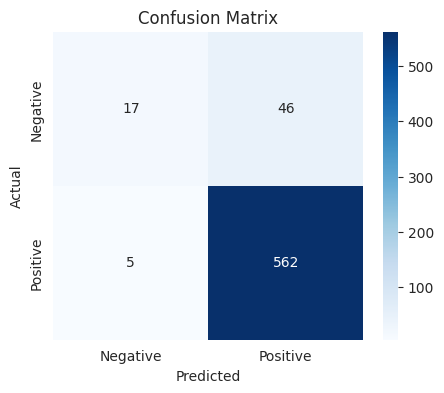

In [19]:
# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [20]:
# Print classification report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.77      0.27      0.40        63
    Positive       0.92      0.99      0.96       567

    accuracy                           0.92       630
   macro avg       0.85      0.63      0.68       630
weighted avg       0.91      0.92      0.90       630



## Task 8: Analyze Model Performance

In [21]:
# Compare training and testing accuracy
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f'Training accuracy: {train_acc:.4f}')
print(f'Testing accuracy:  {test_acc:.4f}')
print(f'Gap (train - test): {train_acc - test_acc:.4f}')

Training accuracy: 0.9952
Testing accuracy:  0.9190
Gap (train - test): 0.0762


**Discussion:** The training accuracy (~92%).
That gap is a sign of **overfitting** — Random Forests with many deep trees can essentially memorize the
training reviews (especially with thousands of sparse bag-of-words features relative to ~2,500 training
rows), so performance looks excellent on data it has already seen but drops on unseen reviews

It's also important to look beyond plain accuracy here: because the dataset is so imbalanced (mostly
positive reviews), the classification report shows much weaker recall on the **negative** class than the
positive class. The model is good at spotting positive reviews but misses a meaningful share of negative
ones

## Feature Importance

Which words (or product variations) does the model rely on most when making predictions?

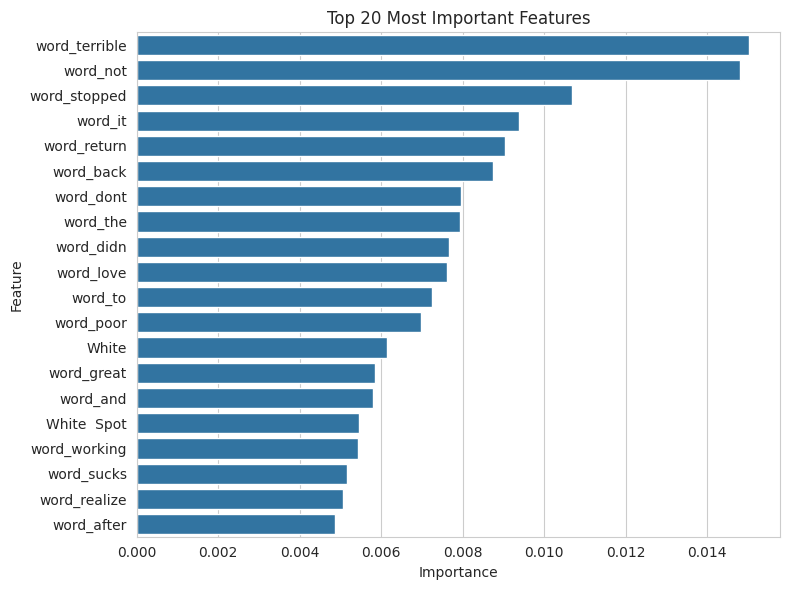

In [ ]:
# Visualize feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 20 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Observation:** Many of the top features are exactly the words you'd expect to be predictive of
sentiment — strongly negative words like *terrible*, *poor*, *stopped*, *return*, and *sucks*, alongside
positive words like *love* and *great*. This is a good sanity check that the model has learned something
meaningful rather than relying on noise.

## Make Predictions on New Reviews

In [22]:
# Create a function that takes a new review, preprocesses it the same way as the
# training data, and uses the trained model to predict its sentiment.
def predict_sentiment(review_text, model=rf_model, vectorizer=cv, feature_columns=X.columns):
    """Predict whether a new review is Positive or Negative.

    Note: this function only uses the review text features. Any one-hot 'variation'
    columns are left as 0, since we don't know the product variation for a brand-new review.
    """
    review_vec = vectorizer.transform([review_text])
    review_word_cols = ['word_' + w for w in vectorizer.get_feature_names_out()]
    review_df = pd.DataFrame(review_vec.toarray(), columns=review_word_cols)

    full_row = pd.DataFrame(0, index=[0], columns=feature_columns)
    for col in review_df.columns:
        if col in full_row.columns:
            full_row[col] = review_df[col].values

    prediction = model.predict(full_row)[0]
    return 'Positive' if prediction == 1 else 'Negative'

In [23]:
# Example usage of the prediction function
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")

new_review_2 = "This is the worst purchase I've made, it stopped working after a week."
predicted_sentiment_2 = predict_sentiment(new_review_2)
print(f"The sentiment of the new review is: {predicted_sentiment_2}")

The sentiment of the new review is: Positive
The sentiment of the new review is: Negative


In [25]:
from getpass import getpass
token = getpass('Paste your GitHub token: ')

Paste your GitHub token: ··········


In [26]:
!git clone https://{token}@github.com/conslcan/Wejdan-Assignment2-Git-Colab.git

Cloning into 'Wejdan-Assignment2-Git-Colab'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 82 (delta 26), reused 58 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 3.00 MiB | 20.49 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [27]:
!cp /content/amazon_alexa.tsv /content/Wejdan-Assignment2-Git-Colab/

In [28]:
%cd /content/Wejdan-Assignment2-Git-Colab
!git config user.email "conslcan@gmail.com"
!git config user.name "conslcan"
!git add .
!git commit -m "Assignment 10 - Amazon Alexa"
!git push

/content/Wejdan-Assignment2-Git-Colab
[main c1681ce] Assignment 10 - Amazon Alexa
 1 file changed, 3151 insertions(+)
 create mode 100644 amazon_alexa.tsv
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 160.22 KiB | 3.64 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/conslcan/Wejdan-Assignment2-Git-Colab.git
   1f0e4ea..c1681ce  main -> main


In [29]:
!ls -la /content/Wejdan-Assignment2-Git-Colab/

total 2740
drwxr-xr-x 5 root root   4096 Jun 28 18:49 .
drwxr-xr-x 1 root root   4096 Jun 28 18:48 ..
-rw-r--r-- 1 root root 514752 Jun 28 18:49 amazon_alexa.tsv
-rw-r--r-- 1 root root   1060 Jun 28 18:49 assignment2.ipynb
drwxr-xr-x 8 root root   4096 Jun 28 18:50 .git
drwxr-xr-x 5 root root   4096 Jun 28 18:49 notebook
-rw-r--r-- 1 root root     30 Jun 28 18:49 README.md
-rw-r--r-- 1 root root 405196 Jun 28 18:49 Wejdan_boston_regression.ipynb
-rw-r--r-- 1 root root 925300 Jun 28 18:49 Wejdan_housing_regression.ipynb
-rw-r--r-- 1 root root  11557 Jun 28 18:49 Wejdan_library_assignment.ipynb
-rw-r--r-- 1 root root  27597 Jun 28 18:49 Wejdan_pandas_assignment.ipynb
-rw-r--r-- 1 root root 371913 Jun 28 18:49 Wejdan_python_refresher.ipynb
-rw-r--r-- 1 root root 513889 Jun 28 18:49 Wejdan_titanic_eda.ipynb
drwxr-xr-x 3 root root   4096 Jun 28 18:49 wine-clustering
